# ML_2

## Libraries

In [43]:
import pandas as pd 
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_squared_error
from sklearn.metrics import r2_score
import numpy as np
import matplotlib.pyplot as plt


## Load Data

In [2]:
data = pd.read_csv('housing.csv')

## Exploring Data

### General Exploring 

In [5]:
data

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value
0,-122.23,37.88,41,880,129.0,322,126,8.3252,452600
1,-122.22,37.86,21,7099,1106.0,2401,1138,8.3014,358500
2,-122.24,37.85,52,1467,190.0,496,177,7.2574,352100
3,-122.25,37.85,52,1274,235.0,558,219,5.6431,341300
4,-122.25,37.85,52,1627,280.0,565,259,3.8462,342200
...,...,...,...,...,...,...,...,...,...
20635,-121.09,39.48,25,1665,374.0,845,330,1.5603,78100
20636,-121.21,39.49,18,697,150.0,356,114,2.5568,77100
20637,-121.22,39.43,17,2254,485.0,1007,433,1.7000,92300
20638,-121.32,39.43,18,1860,409.0,741,349,1.8672,84700


In [6]:
data.shape

(20640, 9)

In [7]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 9 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   longitude           20640 non-null  float64
 1   latitude            20640 non-null  float64
 2   housing_median_age  20640 non-null  int64  
 3   total_rooms         20640 non-null  int64  
 4   total_bedrooms      20433 non-null  float64
 5   population          20640 non-null  int64  
 6   households          20640 non-null  int64  
 7   median_income       20640 non-null  float64
 8   median_house_value  20640 non-null  int64  
dtypes: float64(4), int64(5)
memory usage: 1.4 MB


In [21]:
data.duplicated().sum()

np.int64(0)

In [8]:
data.describe()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value
count,20640.000000,20640.000000,20640.000000,20640.000000,20433.000000,20640.000000,20640.000000,20640.000000,20640.000000
mean,-119.569704,35.631861,28.639486,2635.763081,537.870553,1425.476744,499.539680,3.870671,206855.816909
std,2.003532,2.135952,12.585558,2181.615252,421.385070,1132.462122,382.329753,1.899822,115395.615874
min,-124.350000,32.540000,1.000000,2.000000,1.000000,3.000000,1.000000,0.499900,14999.000000
25%,-121.800000,33.930000,18.000000,1447.750000,296.000000,787.000000,280.000000,2.563400,119600.000000
50%,-118.490000,34.260000,29.000000,2127.000000,435.000000,1166.000000,409.000000,3.534800,179700.000000
75%,-118.010000,37.710000,37.000000,3148.000000,647.000000,1725.000000,605.000000,4.743250,264725.000000
max,-114.310000,41.950000,52.000000,39320.000000,6445.000000,35682.000000,6082.000000,15.000100,500001.000000


### Data longitude exploring 

In [9]:
data['longitude'].isna().sum()

np.int64(0)

In [10]:
data['longitude'].value_counts()

longitude
-118.31    162
-118.30    160
-118.29    148
-118.27    144
-118.32    142
          ... 
-123.13      1
-123.43      1
-123.12      1
-116.27      1
-123.26      1
Name: count, Length: 844, dtype: int64

In [11]:
data['longitude'].info()

<class 'pandas.core.series.Series'>
RangeIndex: 20640 entries, 0 to 20639
Series name: longitude
Non-Null Count  Dtype  
--------------  -----  
20640 non-null  float64
dtypes: float64(1)
memory usage: 161.4 KB


In [12]:
data['longitude'].describe()

count    20640.000000
mean      -119.569704
std          2.003532
min       -124.350000
25%       -121.800000
50%       -118.490000
75%       -118.010000
max       -114.310000
Name: longitude, dtype: float64

In [13]:
data['longitude'].duplicated().sum()

np.int64(19796)

In [14]:
invalid_long = []
for i in data['longitude']:
    if i>=0 : 
        invalid_long.append(i)
    else:
        pass
# no invalid long 

### Data latitude Exploring 

In [15]:
data['latitude'].info()

<class 'pandas.core.series.Series'>
RangeIndex: 20640 entries, 0 to 20639
Series name: latitude
Non-Null Count  Dtype  
--------------  -----  
20640 non-null  float64
dtypes: float64(1)
memory usage: 161.4 KB


In [16]:
data['latitude'].describe()

count    20640.000000
mean        35.631861
std          2.135952
min         32.540000
25%         33.930000
50%         34.260000
75%         37.710000
max         41.950000
Name: latitude, dtype: float64

In [17]:
data['latitude'].isna().sum()

np.int64(0)

In [18]:
data['latitude'].duplicated().sum()

np.int64(19778)

In [19]:
invalid_lan = []
for i in data['latitude']:
    if i>=0 : 
        invalid_lan.append(i)
    else:
        pass
# no invalid long 

### Data housing_medin_age Exploring 

In [20]:
data['housing_median_age'].info()

<class 'pandas.core.series.Series'>
RangeIndex: 20640 entries, 0 to 20639
Series name: housing_median_age
Non-Null Count  Dtype
--------------  -----
20640 non-null  int64
dtypes: int64(1)
memory usage: 161.4 KB


In [21]:
data['housing_median_age'].describe()

count    20640.000000
mean        28.639486
std         12.585558
min          1.000000
25%         18.000000
50%         29.000000
75%         37.000000
max         52.000000
Name: housing_median_age, dtype: float64

In [22]:
data['housing_median_age'].isna().sum()

np.int64(0)

In [28]:
data[data['housing_median_age']==1]

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value
3130,-117.95,35.08,1,83,15.0,32,15,4.8750,141700
12286,-116.95,33.86,1,6,2.0,8,2,1.6250,55000
18972,-122.00,38.23,1,2062,343.0,872,268,5.2636,191300
19536,-120.93,37.65,1,2254,328.0,402,112,4.2500,189200


### Data total_rooms Exploring 

In [24]:
data['total_rooms'].info()

<class 'pandas.core.series.Series'>
RangeIndex: 20640 entries, 0 to 20639
Series name: total_rooms
Non-Null Count  Dtype
--------------  -----
20640 non-null  int64
dtypes: int64(1)
memory usage: 161.4 KB


In [25]:
data['total_rooms'].describe()

count    20640.000000
mean      2635.763081
std       2181.615252
min          2.000000
25%       1447.750000
50%       2127.000000
75%       3148.000000
max      39320.000000
Name: total_rooms, dtype: float64

In [26]:
data[data['total_rooms']==2]

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value
3126,-117.79,35.21,4,2,2.0,6,2,2.375,137500


In [27]:
data['total_rooms'].isna().sum()

np.int64(0)

### Data total_bedrooms Exploring 

In [31]:
data['total_bedrooms'].info()

<class 'pandas.core.series.Series'>
RangeIndex: 20640 entries, 0 to 20639
Series name: total_bedrooms
Non-Null Count  Dtype  
--------------  -----  
20433 non-null  float64
dtypes: float64(1)
memory usage: 161.4 KB


In [32]:
data['total_bedrooms'].describe()

count    20433.000000
mean       537.870553
std        421.385070
min          1.000000
25%        296.000000
50%        435.000000
75%        647.000000
max       6445.000000
Name: total_bedrooms, dtype: float64

In [33]:
data['total_bedrooms'].isna().sum()

np.int64(207)

In [34]:
data['total_bedrooms'].value_counts()

total_bedrooms
280.0     55
331.0     51
345.0     50
343.0     49
393.0     49
          ..
2009.0     1
2249.0     1
3114.0     1
1625.0     1
1742.0     1
Name: count, Length: 1923, dtype: int64

In [38]:
data[data['total_bedrooms']=="Null"]

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value


In [40]:
data['total_bedrooms'].isna()

0        False
1        False
2        False
3        False
4        False
         ...  
20635    False
20636    False
20637    False
20638    False
20639    False
Name: total_bedrooms, Length: 20640, dtype: bool

In [41]:
data[data['total_bedrooms'].isnull()]   

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value
290,-122.16,37.77,47,1256,NaN,570,218,4.3750,161900
341,-122.17,37.75,38,992,NaN,732,259,1.6196,85100
538,-122.28,37.78,29,5154,NaN,3741,1273,2.5762,173400
563,-122.24,37.75,45,891,NaN,384,146,4.9489,247100
696,-122.10,37.69,41,746,NaN,387,161,3.9063,178400
...,...,...,...,...,...,...,...,...,...
20267,-119.19,34.20,18,3620,NaN,3171,779,3.3409,220500
20268,-119.18,34.19,19,2393,NaN,1938,762,1.6953,167400
20372,-118.88,34.17,15,4260,NaN,1701,669,5.1033,410700
20460,-118.75,34.29,17,5512,NaN,2734,814,6.6073,258100


In [42]:
# we can remove null cuase it s only 1 percent of our data and we can change type to int its better . 

### Data population Exploring

In [3]:
data['population'].info()

<class 'pandas.core.series.Series'>
RangeIndex: 20640 entries, 0 to 20639
Series name: population
Non-Null Count  Dtype
--------------  -----
20640 non-null  int64
dtypes: int64(1)
memory usage: 161.4 KB


In [4]:
data['population'].describe()

count    20640.000000
mean      1425.476744
std       1132.462122
min          3.000000
25%        787.000000
50%       1166.000000
75%       1725.000000
max      35682.000000
Name: population, dtype: float64

In [5]:
data['population'].isna().sum()

np.int64(0)

In [6]:
data[data['population']==3]

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value
5342,-118.44,34.04,16,18,6.0,3,4,0.536,350000


### Data housholds Exploring

In [7]:
data['households'].info()

<class 'pandas.core.series.Series'>
RangeIndex: 20640 entries, 0 to 20639
Series name: households
Non-Null Count  Dtype
--------------  -----
20640 non-null  int64
dtypes: int64(1)
memory usage: 161.4 KB


In [8]:
data['households'].describe()

count    20640.000000
mean       499.539680
std        382.329753
min          1.000000
25%        280.000000
50%        409.000000
75%        605.000000
max       6082.000000
Name: households, dtype: float64

In [9]:
data['households'].isna().sum()

np.int64(0)

In [10]:
data[data['households']==1]

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value
16171,-122.5,37.79,52,8,1.0,13,1,15.0001,500001


### Data median_income Exploring 

In [11]:
data['median_income'].info()

<class 'pandas.core.series.Series'>
RangeIndex: 20640 entries, 0 to 20639
Series name: median_income
Non-Null Count  Dtype  
--------------  -----  
20640 non-null  float64
dtypes: float64(1)
memory usage: 161.4 KB


In [12]:
data['median_income'].describe()

count    20640.000000
mean         3.870671
std          1.899822
min          0.499900
25%          2.563400
50%          3.534800
75%          4.743250
max         15.000100
Name: median_income, dtype: float64

In [13]:
data['median_income'].isna().sum()

np.int64(0)

In [15]:
# we have * 10000 to see main prize 0.499900 =====>4999.00

### Data  median_house_value Exploring 

In [16]:
data['median_house_value'].info()

<class 'pandas.core.series.Series'>
RangeIndex: 20640 entries, 0 to 20639
Series name: median_house_value
Non-Null Count  Dtype
--------------  -----
20640 non-null  int64
dtypes: int64(1)
memory usage: 161.4 KB


In [17]:
data['median_house_value'].describe()

count     20640.000000
mean     206855.816909
std      115395.615874
min       14999.000000
25%      119600.000000
50%      179700.000000
75%      264725.000000
max      500001.000000
Name: median_house_value, dtype: float64

In [18]:
data['median_house_value'].isna().sum()

np.int64(0)

### Report of Data 

In [22]:
"""   
longitude =  طول جغرافیایی محل خانه 
latitude = عرض جغرافیایی محل خانه 
house_medin_age = میانه سن خانه های آن منطقه 
total_rooms = مجموع تعداد اتاق های تمام خانه های آن بلوک آماری 
total_bedrooms = مجموع تعداد اتاق خواب ها در آن بلوک 
population = جمعیت ساکن آن بلوک آماری 
households = تعداد خانوار ها 
median_income = درآمد میانه خانوار ها 
median_house_value = قیمت میانه خانه 


Data cleaning : 

1. we can remove null cuase it s only 1 percent of our data and we can change type to int its better or . ( total_bedrooms ) 
2. # we have * 10000 to see main prize 0.499900 =====> 4999.00   ( median_income)


all of them is ok in first look ! 

"""

'   \nlongitude =  طول جغرافیایی محل خانه \nlatitude = عرض جغرافیایی محل خانه \nhouse_medin_age = میانه سن خانه های آن منطقه \ntotal_rooms = مجموع تعداد اتاق های تمام خانه های آن بلوک آماری \ntotal_bedrooms = مجموع تعداد اتاق خواب ها در آن بلوک \npopulation = جمعیت ساکن آن بلوک آماری \nhouseholds = تعداد خانوار ها \nmedian_income = درآمد میانه خانوار ها \nmedian_house_value = قیمت میانه خانه \n\n\nData cleaning : \n\n1. we can remove null cuase it s only 1 percent of our data and we can change type to int its better or . ( total_bedrooms ) \n2. # we have * 10000 to see main prize 0.499900 =====> 4999.00   ( median_income)\n\n\nall of them is ok in first look ! \n\n'

## Data cleaning & Preprocessing 

### total_bedrooms

In [23]:
data['total_bedrooms'] = data['total_bedrooms'].fillna(data['total_bedrooms'].median())

In [24]:
data['total_bedrooms'].isna().sum()

np.int64(0)

In [25]:
data['total_bedrooms'] = data['total_bedrooms'].astype(int)

In [26]:
data['total_bedrooms'].info()

<class 'pandas.core.series.Series'>
RangeIndex: 20640 entries, 0 to 20639
Series name: total_bedrooms
Non-Null Count  Dtype
--------------  -----
20640 non-null  int64
dtypes: int64(1)
memory usage: 161.4 KB


In [27]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 9 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   longitude           20640 non-null  float64
 1   latitude            20640 non-null  float64
 2   housing_median_age  20640 non-null  int64  
 3   total_rooms         20640 non-null  int64  
 4   total_bedrooms      20640 non-null  int64  
 5   population          20640 non-null  int64  
 6   households          20640 non-null  int64  
 7   median_income       20640 non-null  float64
 8   median_house_value  20640 non-null  int64  
dtypes: float64(3), int64(6)
memory usage: 1.4 MB


In [28]:
data.duplicated().sum()

np.int64(0)

In [29]:
data.isna().sum()

longitude             0
latitude              0
housing_median_age    0
total_rooms           0
total_bedrooms        0
population            0
households            0
median_income         0
median_house_value    0
dtype: int64

### preprocessing 

In [30]:
X = data.drop('median_house_value', axis=1)
y = data['median_house_value']

In [32]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

### Scaling 

- z_score

In [36]:
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

## Train model

In [38]:
model = LinearRegression()

model.fit(X_train, y_train)

LinearRegression()

In [39]:
y_pred = model.predict(X_test)

In [42]:
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print("="*40)
print("Model Evaluation")
print("="*40)
print(f"MAE  : {mae:.2f}")
print(f"MSE  : {mse:.2f}")
print(f"RMSE : {rmse:.2f}")
print(f"R²   : {r2:.4f}")

Model Evaluation
MAE  : 51810.48
MSE  : 5059928371.17
RMSE : 71133.17
R²   : 0.6139


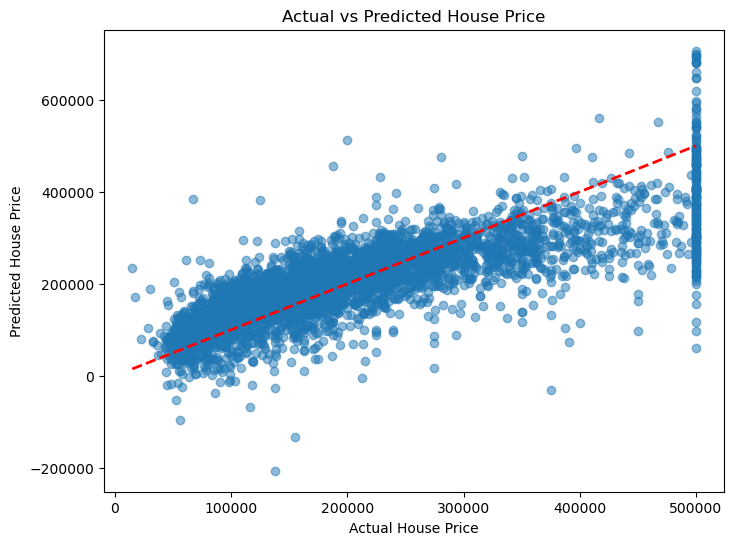

In [44]:
plt.figure(figsize=(8,6))

plt.scatter(y_test, y_pred, alpha=0.5)

plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    'r--',
    linewidth=2
)

plt.xlabel("Actual House Price")
plt.ylabel("Predicted House Price")
plt.title("Actual vs Predicted House Price")

plt.show()

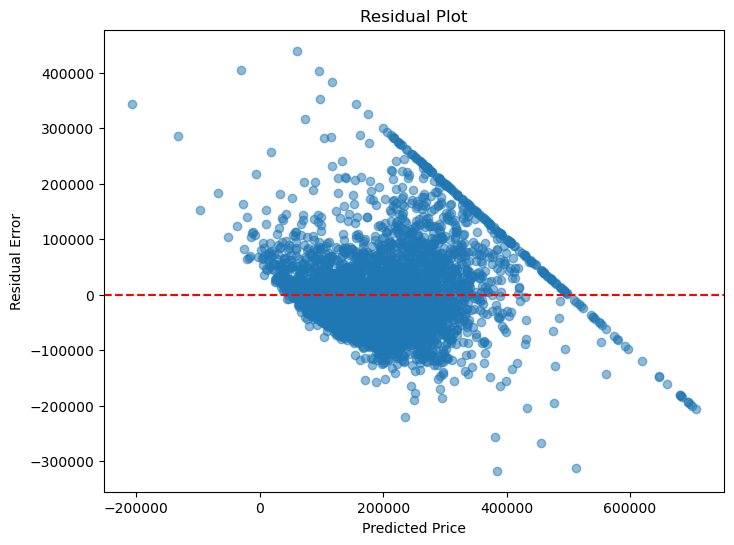

In [45]:
residuals = y_test - y_pred

plt.figure(figsize=(8,6))

plt.scatter(y_pred, residuals, alpha=0.5)

plt.axhline(0, color='red', linestyle='--')

plt.xlabel("Predicted Price")
plt.ylabel("Residual Error")
plt.title("Residual Plot")

plt.show()

## Feature importance

In [53]:
importance = pd.DataFrame({
    "Feature": X.columns,
    "Coefficient": model.coef_,
    "Importance": np.abs(model.coef_)
})

importance = importance.sort_values(
    by="Importance",
    ascending=False
)

print(importance)

              Feature   Coefficient    Importance
1            latitude -90698.848803  90698.848803
0           longitude -85503.218153  85503.218153
7       median_income  77194.699466  77194.699466
4      total_bedrooms  48712.343341  48712.343341
5          population -43766.491159  43766.491159
3         total_rooms -17805.418501  17805.418501
6          households  17654.500659  17654.500659
2  housing_median_age  14905.906448  14905.906448


In [60]:
print("Top Important Features")
print(importance[['Feature','Importance']])

Top Important Features
              Feature    Importance
1            latitude  90698.848803
0           longitude  85503.218153
7       median_income  77194.699466
4      total_bedrooms  48712.343341
5          population  43766.491159
3         total_rooms  17805.418501
6          households  17654.500659
2  housing_median_age  14905.906448


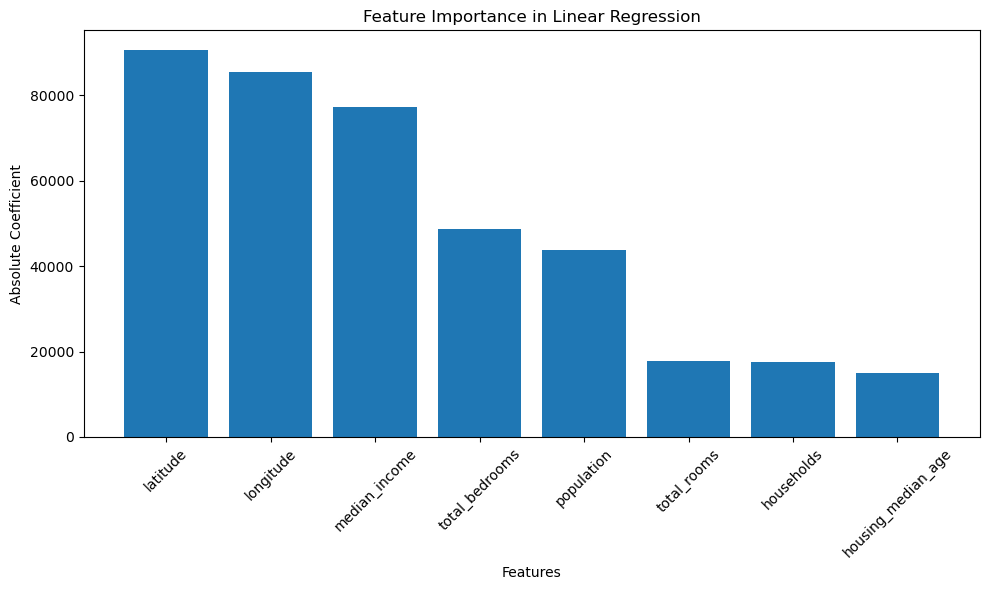

In [57]:
plt.figure(figsize=(10,6))

plt.bar(
    importance["Feature"],
    importance["Importance"]
)

plt.xticks(rotation=45)
plt.xlabel("Features")
plt.ylabel("Absolute Coefficient")
plt.title("Feature Importance in Linear Regression")

plt.tight_layout()
plt.show()

In [58]:
print("Most Important Feature:")
print(importance.iloc[0])

Most Important Feature:
Feature            latitude
Coefficient   -90698.848803
Importance     90698.848803
Name: 1, dtype: object


In [59]:
print("Least Important Feature:")
print(importance.iloc[-1])

Least Important Feature:
Feature        housing_median_age
Coefficient          14905.906448
Importance           14905.906448
Name: 2, dtype: object


## sample with 10.000

In [66]:
data_10000 = data.sample(n=10000, random_state=42)

In [67]:
X = data_10000.drop("median_house_value", axis=1)
y = data_10000["median_house_value"]

In [68]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [69]:
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [71]:
model = LinearRegression()

model.fit(X_train, y_train)



LinearRegression()

In [72]:
y_pred = model.predict(X_test)

In [73]:
mae_10000 = mean_absolute_error(y_test, y_pred)
mse_10000 = mean_squared_error(y_test, y_pred)
rmse_10000 = np.sqrt(mse_10000)
r2_10000 = r2_score(y_test, y_pred)

print("="*40)
print("Model Evaluation (10000 Samples)")
print("="*40)
print(f"MAE  : {mae_10000:.2f}")
print(f"MSE  : {mse_10000:.2f}")
print(f"RMSE : {rmse_10000:.2f}")
print(f"R²   : {r2_10000:.4f}")

Model Evaluation (10000 Samples)
MAE  : 51630.35
MSE  : 4962412820.82
RMSE : 70444.40
R²   : 0.6438


In [74]:
comparison = pd.DataFrame({
    "Metric": ["MAE", "MSE", "RMSE", "R²"],
    "Full Dataset": [mae, mse, rmse, r2],
    "10000 Samples": [mae_10000, mse_10000, rmse_10000, r2_10000]
})

print(comparison)

  Metric  Full Dataset  10000 Samples
0    MAE  5.181048e+04   5.163035e+04
1    MSE  5.059928e+09   4.962413e+09
2   RMSE  7.113317e+04   7.044440e+04
3     R²  6.138665e-01   6.438444e-01


In [75]:
comparison.set_index("Metric", inplace=True)
print(comparison.round(2))

        Full Dataset  10000 Samples
Metric                             
MAE     5.181048e+04   5.163035e+04
MSE     5.059928e+09   4.962413e+09
RMSE    7.113317e+04   7.044440e+04
R²      6.100000e-01   6.400000e-01


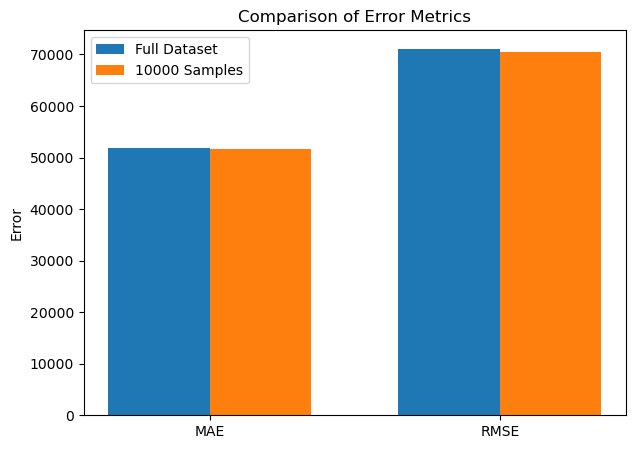

In [76]:
metrics = ["MAE", "RMSE"]

full_dataset = [mae, rmse]
sample_dataset = [mae_10000, rmse_10000]

x = np.arange(len(metrics))
width = 0.35

plt.figure(figsize=(7,5))

plt.bar(x - width/2, full_dataset, width, label="Full Dataset")
plt.bar(x + width/2, sample_dataset, width, label="10000 Samples")

plt.xticks(x, metrics)
plt.ylabel("Error")
plt.title("Comparison of Error Metrics")
plt.legend()

plt.show()

In [77]:
print(f"R² (Full Dataset): {r2:.4f}")
print(f"R² (10000 Samples): {r2_10000:.4f}")

R² (Full Dataset): 0.6139
R² (10000 Samples): 0.6438


In [78]:
# نمودار و مقایسه ها انجام شد 